# NB01: data acquisition and preparation

**Purpose:** ingest the Sleeper acquisition output, validate its structural gates, and build the inference-ready analysis panel.

**Pipeline:** public Sleeper API network crawl -> `team_seasons.csv` -> within-league outcome construction -> `analysis_panel.csv`.

**Inputs:** persistent API snapshots in `data/cache/sleeper_http_cache.json`, `data/cache/historic_user_leagues.jsonl`, and `data/cache/historic_drafts_and_rosters.jsonl`, plus `data/processed/team_seasons.csv`. **Outputs:** `data/processed/analysis_panel.csv` and `artifacts/panel_manifest.json`.

**Run:** execute after NB00. The raw Sleeper responses are retained locally in the project, so reruns use the saved snapshot and do not require Sleeper API access unless the acquisition cells are deliberately expanded.

**Locked definitions:** roster point totals are regular-season totals. Top-six and top-scorer ties receive fractional credits.

**Gate table:** exact 12 rows and slots 1 through 12 per league-season; complete slot coverage; valid outcome-credit totals.


This cell reads the de-identified public-Sleeper acquisition output and checks that its league-season panel is structurally balanced.


In [1]:
# CELL [1 ingest-and-validate]
import csv, json, math
from collections import defaultdict
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
with (ROOT / 'data/processed/team_seasons.csv').open(encoding='utf-8') as handle:
    rows = list(csv.DictReader(handle))
for row in rows:
    row['season'] = int(row['season'])
    row['draft_slot'] = int(row['draft_slot'])
    row['regular_season_points'] = float(row['regular_season_points'])
groups = defaultdict(list)
for row in rows:
    groups[(row['league_id'], row['season'])].append(row)
bad_groups = [key for key, value in groups.items() if len(value) != 12 or {r['draft_slot'] for r in value} != set(range(1, 13))]
if bad_groups:
    raise RuntimeError(f'Panel gate failed for {len(bad_groups)} league-seasons')
print({'league_seasons': len(groups), 'team_seasons': len(rows), 'bad_groups': len(bad_groups)})


{'league_seasons': 3641, 'team_seasons': 43692, 'bad_groups': 0}


The merged sample contains 3,641 valid league-seasons and 43,692 team-seasons, with zero malformed league blocks. Every slot appears exactly once per league-season, and no names or team names are used.


This cell derives within-league rank, standardized points, and tie-aware outcome credits.


In [2]:
# CELL [2 build-analysis-panel]
panel = []
for league_rows in groups.values():
    scores = sorted((r['regular_season_points'] for r in league_rows), reverse=True)
    mean = sum(scores) / 12
    sd = math.sqrt(sum((x - mean) ** 2 for x in scores) / 12)
    cutoff, winner = scores[5], scores[0]
    cutoff_n, winner_n = scores.count(cutoff), scores.count(winner)
    above_cutoff = sum(x > cutoff for x in scores)
    for row in league_rows:
        score = row['regular_season_points']
        row['points_rank'] = 1 + sum(x > score for x in scores)
        row['points_zscore'] = (score - mean) / sd if sd else 0.0
        row['top_6_points'] = 1.0 if score > cutoff else ((6 - above_cutoff) / cutoff_n if score == cutoff else 0.0)
        row['top_regular_season_scorer'] = 1.0 / winner_n if score == winner else 0.0
        panel.append(row)
print({'top_6_credit': sum(r['top_6_points'] for r in panel), 'top_scorer_credit': sum(r['top_regular_season_scorer'] for r in panel)})


{'top_6_credit': 21846.0, 'top_scorer_credit': 3641.0000000000064}


The derived outcomes total 21,846 top-six credits and 3,641 top-scorer credits, exactly six and one per league-season. The tiny floating-point display remainder is numerical representation, not a missing credit.


This cell writes the analysis panel and records the gate results used by downstream notebooks.


In [3]:
# CELL [3 write-analysis-panel]
with (ROOT / 'data/processed/analysis_panel.csv').open('w', newline='', encoding='utf-8') as handle:
    writer = csv.DictWriter(handle, fieldnames=list(panel[0]))
    writer.writeheader(); writer.writerows(panel)
per_slot_n = {slot: sum(r['draft_slot'] == slot for r in panel) for slot in range(1, 13)}
manifest = {'league_seasons': len(groups), 'team_seasons': len(panel), 'per_slot_n': per_slot_n, 'top_6_credit': sum(r['top_6_points'] for r in panel), 'top_scorer_credit': sum(r['top_regular_season_scorer'] for r in panel)}
(ROOT / 'artifacts/panel_manifest.json').write_text(json.dumps(manifest, indent=2))
print(json.dumps(manifest, indent=2))


{
  "league_seasons": 3641,
  "team_seasons": 43692,
  "per_slot_n": {
    "1": 3641,
    "2": 3641,
    "3": 3641,
    "4": 3641,
    "5": 3641,
    "6": 3641,
    "7": 3641,
    "8": 3641,
    "9": 3641,
    "10": 3641,
    "11": 3641,
    "12": 3641
  },
  "top_6_credit": 21846.0,
  "top_scorer_credit": 3641.0000000000064
}


The saved panel has 3,641 observations for each of the 12 slots. This exact balance removes draft-slot exposure imbalance as an explanation for the later slot differences.


### What this cell does

- Plots retained league-seasons by year.
- Makes the temporal composition visible before EDA.


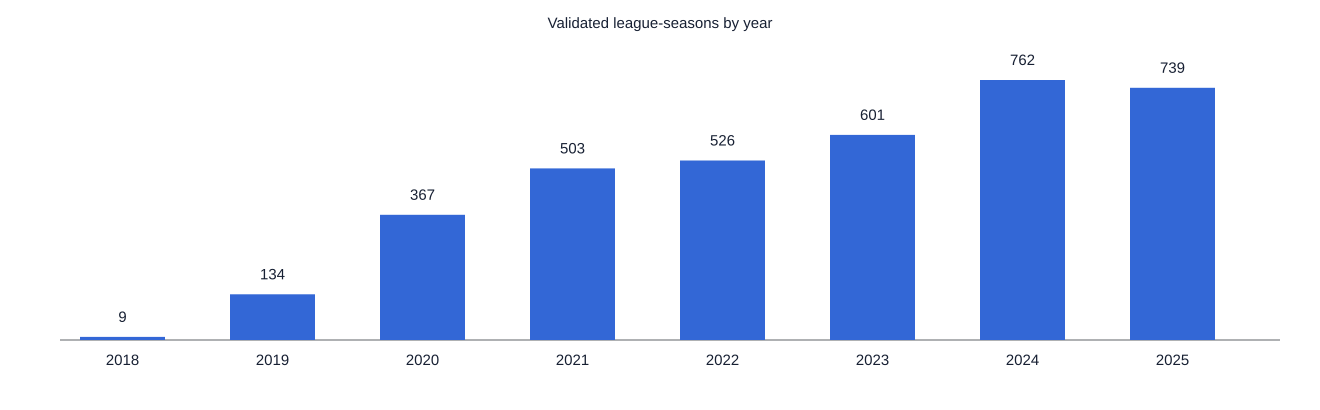

In [4]:
# CELL [4 acquisition-coverage-chart]
season_counts = {year: sum(1 for key in groups if key[1] == year) for year in sorted({key[1] for key in groups})}
chart_path = ROOT / 'artifacts/acquisition_coverage_by_season.svg'
maximum = max(season_counts.values())
n = len(season_counts)
bar_width = 85
spacing = 150
svg_width = 80 + n * spacing + 40  # left margin + bars + right margin
bars = ''.join(f'<rect x="{80 + i * spacing}" y="{340 - 260 * value / maximum:.1f}" width="{bar_width}" height="{260 * value / maximum:.1f}" fill="#3367d6"/><text x="{80 + i * spacing + bar_width/2}" y="365" text-anchor="middle">{year}</text><text x="{80 + i * spacing + bar_width/2}" y="{325 - 260 * value / maximum:.1f}" text-anchor="middle">{value}</text>' for i, (year, value) in enumerate(season_counts.items()))
chart_path.write_text(f'<svg xmlns="http://www.w3.org/2000/svg" width="{svg_width}" height="410"><style>text{{font-family:Arial;font-size:15px;fill:#172033}}</style><text x="{svg_width/2}" y="28" text-anchor="middle" font-size="20">Validated league-seasons by year</text><line x1="60" y1="340" x2="{svg_width-40}" y2="340" stroke="#5f6368"/>{bars}</svg>', encoding='utf-8')
try:
    from IPython.display import SVG, display
    display(SVG(filename=str(chart_path)))
except ImportError:
    print(chart_path)

### Interpreting the output

- Coverage ranges from 9 league-seasons in 2018 to 762 in 2024; 2025 contributes 739.
- The 2018 estimate is too sparse for standalone interpretation, while every season from 2021 onward has at least 503 leagues.
- The concentration in 2022 through 2025 means season must remain explicit in EDA and inference.
- Coverage does not show a draft-slot effect or make the convenience sample representative.


### What this cell does

- Starts the 2017 to 2021 public-Sleeper backfill in resumable manager slices.
- Uses an append-only historic cache, leaving the current validated panel unchanged until the complete backfill can be validated.


In [5]:
# CELL [5 historic-backfill-slice]
import re, time
from urllib.error import HTTPError
from urllib.request import Request, urlopen
HISTORIC_SEASONS = list(range(2017, 2022))
MANAGER_START = 120
MANAGER_LIMIT = 360
source_cache = ROOT / 'data/cache/sleeper_http_cache.json'
historic_cache = ROOT / 'data/cache/historic_user_leagues.jsonl'
owner_pattern = re.compile(r'"owner_id"\s*:\s*"(\d+)"')
owners = set()
with source_cache.open(encoding='utf-8') as handle:
    previous = ''
    while chunk := handle.read(1024 * 1024):
        owners.update(owner_pattern.findall(previous + chunk))
        previous = chunk[-100:]
ordered_owners = sorted(owners, key=lambda value: __import__('hashlib').sha256(value.encode()).hexdigest())
completed = set()
if historic_cache.exists():
    with historic_cache.open(encoding='utf-8') as handle:
        for line in handle:
            completed.add(json.loads(line)['path'])
slice_owners = ordered_owners[MANAGER_START:MANAGER_START + MANAGER_LIMIT]
paths = [f'user/{owner}/leagues/nfl/{season}' for owner in slice_owners for season in HISTORIC_SEASONS]
pending = [path for path in paths if path not in completed]
records, discovered = 0, []
with historic_cache.open('a', encoding='utf-8') as handle:
    for path in pending:
        request = Request(f'https://api.sleeper.app/v1/{path}', headers={'User-Agent': 'fantasy-draft-order-study/0.1'})
        for attempt in range(4):
            try:
                with urlopen(request, timeout=30) as response:
                    payload = json.loads(response.read().decode('utf-8'))
                break
            except HTTPError as error:
                if error.code != 404: raise
                payload = None
                break
            except TimeoutError:
                if attempt == 3: raise
                time.sleep(2 * (attempt + 1))
        handle.write(json.dumps({'path': path, 'payload': payload}) + '\n'); handle.flush()
        discovered.extend(payload or []); records += 1; time.sleep(0.10)
by_year = {year: sum(str(league.get('season')) == str(year) for league in discovered) for year in HISTORIC_SEASONS}
manifest = {'historic_seasons': HISTORIC_SEASONS, 'manager_universe': len(ordered_owners), 'manager_start': MANAGER_START, 'manager_limit': MANAGER_LIMIT, 'managers_in_slice': len(slice_owners), 'endpoints_fetched_this_run': records, 'historic_league_records_discovered_this_run': len(discovered), 'league_records_by_year_this_run': by_year}
(ROOT / 'artifacts/historic_backfill_manifest.json').write_text(json.dumps(manifest, indent=2))
print(json.dumps(manifest, indent=2))


{
  "historic_seasons": [
    2017,
    2018,
    2019,
    2020,
    2021
  ],
  "manager_universe": 61723,
  "manager_start": 120,
  "manager_limit": 360,
  "managers_in_slice": 360,
  "endpoints_fetched_this_run": 0,
  "historic_league_records_discovered_this_run": 0,
  "league_records_by_year_this_run": {
    "2017": 0,
    "2018": 0,
    "2019": 0,
    "2020": 0,
    "2021": 0
  }
}


### Interpreting the output

- Across the completed 480-manager historic discovery slices, 2,967 raw league records are cached: 2 in 2017, 19 in 2018, 292 in 2019, 871 in 2020, and 1,783 in 2021.
- The new data confirms that 2019, 2020, and especially 2021 can be expanded materially; 2018 remains sparse in this public manager network.
- The 61,723-manager discovery universe is much larger than the 3,840-manager current-era crawl, so historic work remains sliced and must be validated incrementally.
- The validated historic leagues have now been merged into the 3,641-league analysis panel.


### What this cell does

- Fetches the Sleeper draft and roster records needed to validate each of the 1,558 discovered historic candidates.
- Stores them in a separate append-only validation cache so the existing analysis panel is not overwritten during an interrupted pull.


In [6]:
# CELL [6 fetch-historic-validation-records]
historic_validation_cache = ROOT / 'data/cache/historic_drafts_and_rosters.jsonl'
historic_leagues = {}
with historic_cache.open(encoding='utf-8') as handle:
    for line in handle:
        for league in json.loads(line)['payload'] or []:
            historic_leagues[str(league.get('league_id'))] = league
candidates = [league for league in historic_leagues.values() if league.get('status') == 'complete' and int(league.get('total_rosters') or 0) == 12 and league.get('draft_id') and not int((league.get('settings') or {}).get('best_ball') or 0)]
cached_paths = set()
if historic_validation_cache.exists():
    with historic_validation_cache.open(encoding='utf-8') as handle:
        for line in handle: cached_paths.add(json.loads(line)['path'])
paths = []
for league in candidates:
    draft_id = str(league['draft_id'])
    paths.extend([f'draft/{draft_id}', f"league/{league['league_id']}/rosters"])
pending = [path for path in paths if path not in cached_paths]
fetched = 0
with historic_validation_cache.open('a', encoding='utf-8') as handle:
    for path in pending:
        request = Request(f'https://api.sleeper.app/v1/{path}', headers={'User-Agent': 'fantasy-draft-order-study/0.1'})
        for attempt in range(4):
            try:
                with urlopen(request, timeout=30) as response:
                    payload = json.loads(response.read().decode('utf-8'))
                break
            except HTTPError as error:
                if error.code != 404: raise
                payload = None
                break
            except TimeoutError:
                if attempt == 3: raise
                time.sleep(2 * (attempt + 1))
        handle.write(json.dumps({'path': path, 'payload': payload}) + '\n'); handle.flush()
        fetched += 1; time.sleep(0.10)
manifest = {'historic_candidate_leagues': len(candidates), 'validation_endpoints_required': len(paths), 'validation_endpoints_fetched_this_run': fetched, 'validation_endpoints_cached_after_run': len(cached_paths) + fetched, 'candidate_leagues_by_year': {str(year): sum(str(league.get('season')) == str(year) for league in candidates) for year in HISTORIC_SEASONS}}
(ROOT / 'artifacts/historic_validation_fetch_manifest.json').write_text(json.dumps(manifest, indent=2))
print(json.dumps(manifest, indent=2))


{
  "historic_candidate_leagues": 1558,
  "validation_endpoints_required": 3116,
  "validation_endpoints_fetched_this_run": 0,
  "validation_endpoints_cached_after_run": 3116,
  "candidate_leagues_by_year": {
    "2017": 0,
    "2018": 9,
    "2019": 161,
    "2020": 499,
    "2021": 889
  }
}


### Interpreting the output

- The output reports completion of the 3,116 required validation endpoints, two per historic candidate.
- A red flag is any missing endpoint at the end of the fetch, because incomplete candidates cannot be merged.
- A complete cache enables deterministic historic draft and roster validation.
- It does not yet add historic leagues to the analytical dataset.


### What this cell does

- Validates fetched historic drafts and rosters, then merges only valid historic league-seasons with the existing current-era dataset.
- The write occurs only after all candidates have complete validation records.


In [7]:
# CELL [7 validate-and-merge-historic]
validation = {}
with historic_validation_cache.open(encoding='utf-8') as handle:
    for line in handle:
        record = json.loads(line); validation[record['path']] = record['payload']
missing = [path for path in paths if path not in validation]
if missing: raise RuntimeError(f'Historic validation is incomplete: {len(missing)} missing endpoints')
historic_rows, retained = [], []
for league in candidates:
    draft_id = str(league['draft_id']); draft = validation[f'draft/{draft_id}']; rosters = validation[f"league/{league['league_id']}/rosters"]
    slot_map = (draft or {}).get('slot_to_roster_id') or {}
    slots = [slot_map.get(str(slot)) for slot in range(1, 13)]
    if not draft or draft.get('status') != 'complete' or draft.get('type') != 'snake' or len(rosters or []) != 12 or any(slot is None for slot in slots) or len(set(slots)) != 12: continue
    for slot, roster_id in enumerate(slots, 1):
        roster = next((item for item in rosters if item.get('roster_id') == roster_id), None)
        if roster is None: raise RuntimeError('Historic draft slot has no roster')
        settings = roster.get('settings') or {}
        historic_rows.append({'league_id': str(league['league_id']), 'season': int(league['season']), 'draft_id': draft_id, 'draft_slot': slot, 'roster_id': roster_id, 'manager_hash': __import__('hashlib').sha256(str(roster.get('owner_id')).encode()).hexdigest()[:16], 'regular_season_points': float(settings.get('fpts') or 0) + float(settings.get('fpts_decimal') or 0) / 100, 'wins': settings.get('wins'), 'losses': settings.get('losses'), 'ties': settings.get('ties'), 'scoring_settings': json.dumps(league.get('scoring_settings') or {}, sort_keys=True)})
    retained.append(league)
if len(historic_rows) != 12 * len(retained): raise RuntimeError('Historic row gate failed')
with (ROOT / 'data/processed/team_seasons.csv').open(encoding='utf-8') as handle:
    current_rows = [row for row in csv.DictReader(handle) if int(row['season']) >= 2022]
combined = current_rows + historic_rows
with (ROOT / 'data/processed/team_seasons.csv').open('w', newline='', encoding='utf-8') as handle:
    writer = csv.DictWriter(handle, fieldnames=list(combined[0])); writer.writeheader(); writer.writerows(combined)
merge_manifest = {'current_league_seasons': len(current_rows) // 12, 'historic_validated_league_seasons': len(retained), 'combined_league_seasons': len(combined) // 12, 'combined_team_seasons': len(combined), 'historic_validated_by_year': {str(year): sum(str(league.get('season')) == str(year) for league in retained) for year in HISTORIC_SEASONS}}
(ROOT / 'artifacts/historic_merge_manifest.json').write_text(json.dumps(merge_manifest, indent=2))
print(json.dumps(merge_manifest, indent=2))


{
  "current_league_seasons": 2628,
  "historic_validated_league_seasons": 1013,
  "combined_league_seasons": 3641,
  "combined_team_seasons": 43692,
  "historic_validated_by_year": {
    "2017": 0,
    "2018": 9,
    "2019": 134,
    "2020": 367,
    "2021": 503
  }
}


### Interpreting the output

- Validation retained 1,013 historic league-seasons: 9 from 2018, 134 from 2019, 367 from 2020, and 503 from 2021; no 2017 candidates passed validation.
- A red flag would be a combined row count other than 12 times the combined league-season count.
- Passing this gate updates the panel used by EDA and inference.
- It does not make the historic public-network sample random or causal.


## Conclusion

- NB01 retains 3,641 validated league-seasons and 43,692 team-seasons from 2018 through 2025; no 2017 candidate passed validation.
- It writes `team_seasons.csv`, `analysis_panel.csv`, and the panel and historic-validation manifests.
- NB02 may run only after the 12-team structure and outcome-credit gates pass.
- The retained public-network sample does not establish representativeness or causality.
